In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

# =====================================================================
# 1. 初期パラメータ設定 (Experiment Configurations)
# =====================================================================
# [モデル設定]
N = 40                  # 変数の数 (観測の数 P も今回は同じ40)
F = 8.0                 # 強制項
dt = 0.01               # 積分時間ステップ
sampling_dt = 0.05      # 観測・同化の間隔 (6時間相当: 0.25日/5日)
m = 80                  # アンサンブルメンバー数
p = 40                  # 観測点の数 (今回は全点観測なので N と同じ)

# [時間設定]
years = 2
units_per_year = 73.0   # 1年 = 365日 / 5日 = 73ユニット
total_time = years * units_per_year
spin_up_time = units_per_year

steps_total = int(total_time / dt)
steps_spin_up = int(spin_up_time / dt)
sampling_interval = int(sampling_dt / dt)

# [データ同化設定]
H_mat = np.eye(N)                       # 観測演算子 H (全点観測)
R_mat = np.eye(N)                       # 観測誤差共分散 R (対角成分1)

In [2]:
# =====================================================================
# 2. Nature Run (真値) と Observation (観測) の生成 (kadai5準拠)
# =====================================================================

def lorenz96(x, F):
    # x の shape が (N,) でも (N, m) でも、axis=0で一括計算
    return (np.roll(x, -1, axis=0) - np.roll(x, 2, axis=0)) * np.roll(x, 1, axis=0) - x + F

def M(x_in, dt, steps):
    # ルンゲ・クッタ法も全メンバーを並列一括処理
    x_out = x_in.copy()
    for _ in range(steps):
        k1 = lorenz96(x_out, F)
        k2 = lorenz96(x_out + k1 * (dt / 2.0), F)
        k3 = lorenz96(x_out + k2 * (dt / 2.0), F)
        k4 = lorenz96(x_out + k3 * dt, F)
        x_out += (k1 + 2.0*k2 + 2.0*k3 + k4) * (dt / 6.0)
    return x_out

print("Nature Runと観測データを生成中...")
x = np.full(N, F)
x[19] += 0.001 # カオス誘発用の摂動

true_states = []
for s in range(steps_total):
    x = M(x, dt, 1)  # dtステップで1回の積分
    if s >= steps_spin_up and (s - steps_spin_up) % sampling_interval == 0:
        true_states.append(x.copy())
true_states = np.array(true_states)

# [変更点] モダンな乱数生成器 (default_rng) を使用
rng_obs = np.random.default_rng(seed=67) 
noise = rng_obs.normal(loc=0.0, scale=1.0, size=true_states.shape)
noise -= np.mean(noise, axis=0)  # 各変数ごとに平均0に調整
y_o_data = true_states + noise # 観測データ y^o

print("生成完了！")

Nature Runと観測データを生成中...
生成完了！


汎用関数を用いて静的実験(Landのみ観測)を開始します...
事前準備中 (H_mats, W_weights_list の生成)...
1/5: Running FIXED 1.5% ...
2/7: Running Adaptive v_b = 0.0001 ...
3/7: Running Adaptive v_b = 0.0004 ...
4/7: Running Adaptive v_b = 0.0016 ...
5/7: Running Adaptive v_b = 0.0064 ...
6/7: Running Adaptive v_b = 0.0256 ...
7/7: Running Adaptive v_b = 0.1024 ...
8/7: Running Adaptive v_b = 0.4096 ...
全計算完了！ (合計所要時間: 605.16秒)
描画します。


ValueError: 'facecolor' or 'color' argument must be a valid color or sequence of colors.

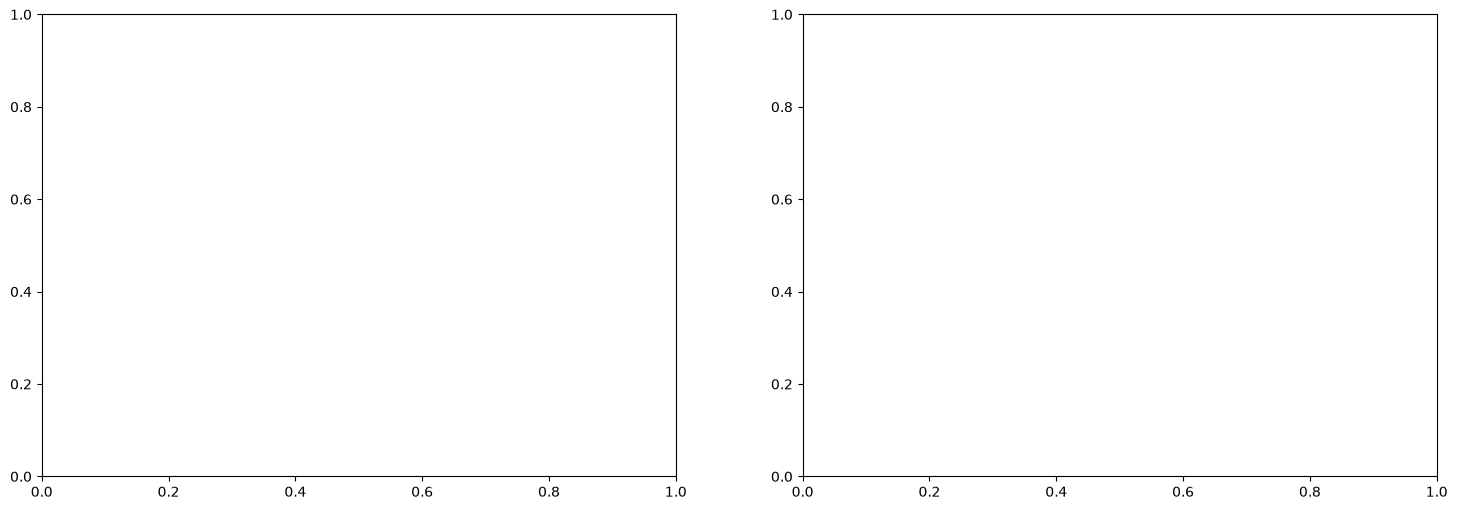

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt

num_cycles = y_o_data.shape[0]
# =====================================================================
# 1. 共通関数（汎用化）
# =====================================================================
def get_experiment_matrices(obs_indices):
    p_obs = len(obs_indices)
    H_mat = np.zeros((p_obs, N))
    for k, j in enumerate(obs_indices):
        H_mat[k, j] = 1.0
    R_mat = np.eye(p_obs)
    return H_mat, R_mat

def get_localization_weights(sigma, obs_indices):
    p_obs = len(obs_indices)
    W_weights = np.zeros((N, p_obs))
    def L(d):
        if d < np.sqrt(10.0 / 3.0) * sigma * 2.0:
            return np.exp(- (d**2) / (2.0 * sigma**2))
        return 0.0
    
    for i in range(N):
        for k, j in enumerate(obs_indices):
            d = min(abs(i - j), N - abs(i - j))
            W_weights[i, k] = L(d)
    return W_weights

# =====================================================================
# 2. 統合型 LETKF コア関数 (SPREAD計算 ＆ 辞書出力対応版)
# =====================================================================
def run_LETKF_Adaptive_Moving_Agile(
    init_delta, 
    v_b_val, 
    move_interval, 
    move_step, 
    swath_size, 
    sigma, 
    H_mats, 
    W_weights_list, 
    obs_indices_history
):
    rng_enkf = np.random.default_rng(seed=42)
    init_noise = rng_enkf.normal(0.0, 0.1, size=(N, m))
    init_noise -= np.mean(init_noise, axis=1, keepdims=True)
    
    x_raw = np.full(N, F)
    x_raw[min(19, N-1)] += 0.001
    X_a = M(x_raw[:, None] + init_noise, dt, steps_spin_up)
    
    delta_array = np.full(N, init_delta)
    v_b = np.full(N, v_b_val)
    R_diag = np.ones(swath_size)
    
    # グラフ描画との互換性を保つため、辞書形式でSPREADも記録
    record = {
        'rmse_gl': np.zeros(num_cycles), 'spr_gl': np.zeros(num_cycles),
        'rmse_ld': np.zeros(num_cycles), 'spr_ld': np.zeros(num_cycles),
        'rmse_oc': np.zeros(num_cycles), 'spr_oc': np.zeros(num_cycles),
        'delta': np.zeros(num_cycles)
    }
    
    for t in range(num_cycles):
        shift = ((t // move_interval) * move_step) % N
        curr_obs_indices = obs_indices_history[shift]
        curr_unobs_indices = np.setdiff1d(np.arange(N), curr_obs_indices)
        
        H_mat = H_mats[shift]
        W_weights = W_weights_list[shift]
        y_o = y_o_data[t, curr_obs_indices]
        
        X_b = M(X_a, dt, sampling_interval)
        if not np.all(np.isfinite(X_b)):
            return record
            
        x_b_mean = np.mean(X_b, axis=1)
        inflation_factor = np.sqrt(1.0 + delta_array) / np.sqrt(m - 1.0)
        Z_b = (X_b - x_b_mean[:, None]) * inflation_factor[:, None]
        Y_b = H_mat @ Z_b
        innovation = y_o - H_mat @ x_b_mean
        
        infl_at_obs = 1.0 + delta_array[curr_obs_indices]
        H_Pf_H_T_diag = np.sum(Y_b**2, axis=1) / infl_at_obs
        
        X_a = np.zeros((N, m))
        delta_array_next = np.zeros(N)
        
        for i in range(N):
            w_i = W_weights[i, :]
            R_loc_inv_diag = np.diag(w_i / R_diag)
            P_a_tilde_inv = np.eye(m) + (Y_b.T @ R_loc_inv_diag @ Y_b)
            
            try:
                D, C = np.linalg.eigh(P_a_tilde_inv)
            except np.linalg.LinAlgError:
                return record
                
            P_a_tilde = C @ np.diag(1.0 / D) @ C.T
            W_mat = C @ np.diag(1.0 / np.sqrt(D)) @ C.T
            w_vec = P_a_tilde @ Y_b.T @ R_loc_inv_diag @ innovation
            T_mat = w_vec[:, None] + np.sqrt(m - 1.0) * W_mat
            X_a[i, :] = x_b_mean[i] + Z_b[i, :] @ T_mat
            
            valid = H_Pf_H_T_diag > 1e-10
            if np.sum(w_i[valid]) > 1e-10:
                mole_alpha = w_i[valid] * (innovation[valid]**2 - R_diag[valid]) / H_Pf_H_T_diag[valid]
                deno_alpha = w_i[valid]
                alpha_o_i = np.sum(mole_alpha) / np.sum(deno_alpha)
                delta_o_i = alpha_o_i - 1.0
                
                alpha_b_i = 1.0 + delta_array[i]
                mole_v = w_i[valid] * ((alpha_b_i * H_Pf_H_T_diag[valid] + R_diag[valid]) / H_Pf_H_T_diag[valid])**2
                v_o_i = 2.0 * np.sum(mole_v) / (np.sum(w_i[valid])**2)
            else:
                delta_o_i, v_o_i = 0.0, 1e10
            
            k_gain = v_b[i] / (v_b[i] + v_o_i)
            delta_a = delta_array[i] + k_gain * (delta_o_i - delta_array[i])
            delta_array_next[i] = np.clip(delta_a, 0.0, 3.0)
            
        delta_array = delta_array_next.copy()
        
        # 記録処理 (SPREAD含む)
        x_a_mean = np.mean(X_a, axis=1)
        var_a = np.var(X_a, axis=1, ddof=1)
        truth = true_states[t]
        
        record['rmse_gl'][t] = np.sqrt(np.mean((x_a_mean - truth)**2))
        record['spr_gl'][t]  = np.sqrt(np.mean(var_a))
        record['rmse_ld'][t] = np.sqrt(np.mean((x_a_mean[curr_obs_indices] - truth[curr_obs_indices])**2))
        record['spr_ld'][t]  = np.sqrt(np.mean(var_a[curr_obs_indices]))
        record['rmse_oc'][t] = np.sqrt(np.mean((x_a_mean[curr_unobs_indices] - truth[curr_unobs_indices])**2))
        record['spr_oc'][t]  = np.sqrt(np.mean(var_a[curr_unobs_indices]))
        record['delta'][t]   = np.mean(delta_array)
            
    return record


# =====================================================================
# 3. 実験の実行とプロット (Land固定観測の再現)
# =====================================================================
if __name__ == "__main__":
    print("汎用関数を用いて静的実験(Landのみ観測)を開始します...")
    start_all = time.time()
    
    # --- Land固定観測の設定 ---
    # move_step = 0 にすることで、常に初期位置(Land)にとどまります。
    CONFIG = {
        "move_interval": 1,
        "move_step": 0, 
        "swath_size": 20,
        "sigma": 3.0
    }
    spin_up = 100 
    
    print("事前準備中 (H_mats, W_weights_list の生成)...")
    H_mats, W_list, obs_hist = [], [], []
    for shift in range(N):
        idx = (np.arange(0, CONFIG["swath_size"]) + shift) % N
        obs_hist.append(idx)
        H, _ = get_experiment_matrices(idx) 
        H_mats.append(H)
        W_list.append(get_localization_weights(CONFIG["sigma"], idx))

    # ① 固定インフレーション 
    # v_b_val = 0.0 にすることで k_gain = 0 となり、完全な固定インフレーションとして機能します。
    print("1/5: Running FIXED 1.5% ...")
    res_fix = run_LETKF_Adaptive_Moving_Agile(
        init_delta=0.015, v_b_val=0.0, 
        move_interval=CONFIG["move_interval"], move_step=CONFIG["move_step"], 
        swath_size=CONFIG["swath_size"], sigma=CONFIG["sigma"], 
        H_mats=H_mats, W_weights_list=W_list, obs_indices_history=obs_hist
    )
    
    # ② 適応的インフレーション (v_b の初期値4パターン)
    vb_list = [0.01**2, 0.02**2, 0.04**2, 0.08**2, 0.16**2, 0.32**2, 0.64**2]  # 適応的インフレーションの v_b の初期値リスト
    labels = [r'$0.01^2$', r'$0.02^2$', r'$0.04^2$', r'$0.08^2$', r'$0.16^2$', r'$0.32^2$', r'$0.64^2$']
    colors = ['black', 'red', 'green', 'blue', 'orange', 'purple', 'brown']
    adaptive_results = []
    
    for i, vb in enumerate(vb_list):
        print(f"{i+2}/7: Running Adaptive v_b = {vb} ...")
        res = run_LETKF_Adaptive_Moving_Agile(
            init_delta=0.01, v_b_val=vb,
            move_interval=CONFIG["move_interval"], move_step=CONFIG["move_step"], 
            swath_size=CONFIG["swath_size"], sigma=CONFIG["sigma"], 
            H_mats=H_mats, W_weights_list=W_list, obs_indices_history=obs_hist
        )
        adaptive_results.append({
            k: np.mean(v[spin_up:]) if k != 'delta' else v for k, v in res.items()
        })
    
    print(f"全計算完了！ (合計所要時間: {time.time() - start_all:.2f}秒)\n描画します。")
    
    

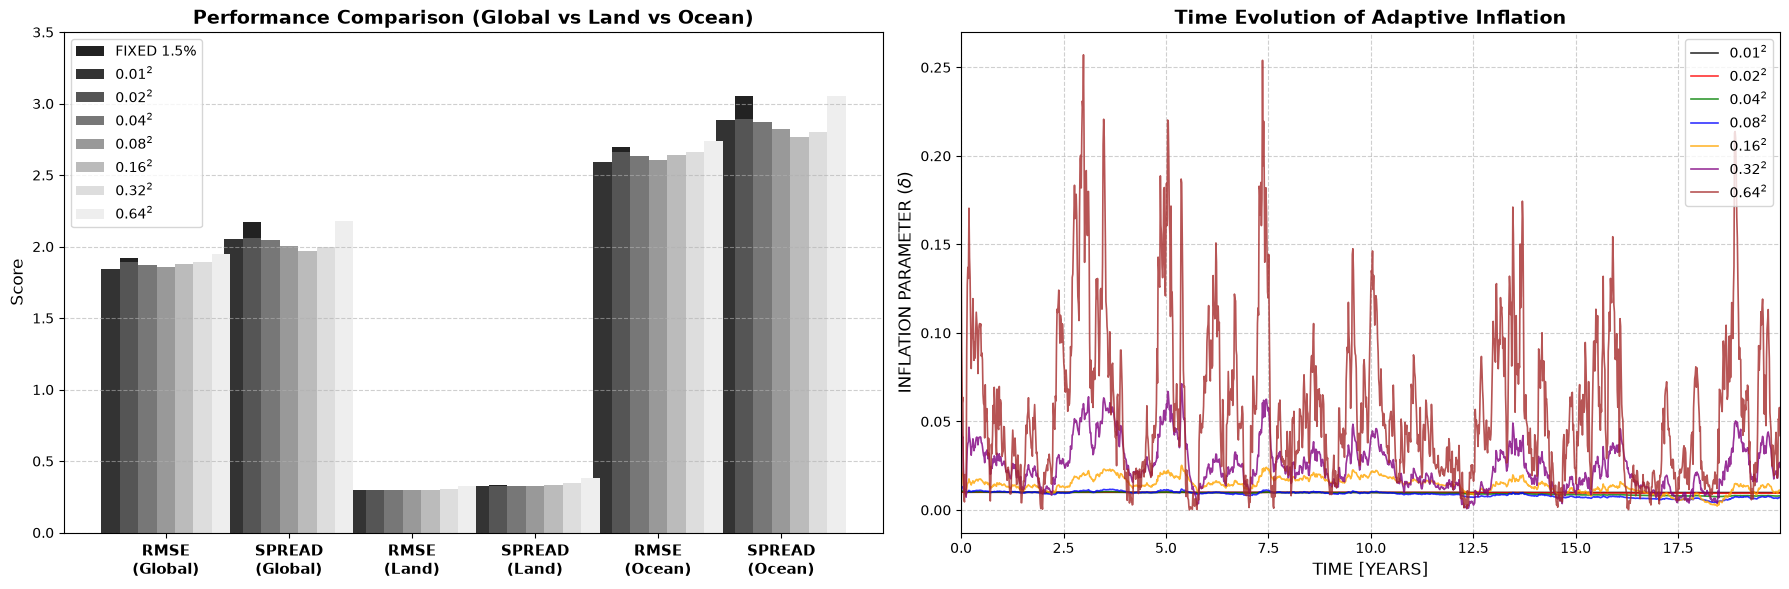

In [4]:
# --- 論文完全再現プロット ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# 【左図】Global, Land, Ocean の領域別比較棒グラフ
groups = ['RMSE\n(Global)', 'SPREAD\n(Global)', 'RMSE\n(Land)', 'SPREAD\n(Land)', 'RMSE\n(Ocean)', 'SPREAD\n(Ocean)']
x = np.arange(len(groups))
width = 0.15

# FIXED の描画
vals_fix = [np.mean(res_fix['rmse_gl'][spin_up:]), np.mean(res_fix['spr_gl'][spin_up:]),
            np.mean(res_fix['rmse_ld'][spin_up:]), np.mean(res_fix['spr_ld'][spin_up:]),
            np.mean(res_fix['rmse_oc'][spin_up:]), np.mean(res_fix['spr_oc'][spin_up:])]
ax1.bar(x - 2*width, vals_fix, width, label='FIXED 1.5%', color='#222222')

# Adaptive の描画
bar_colors = ['#333333','#555555','#777777', '#999999', '#BBBBBB', '#DDDDDD', '#EEEEEE']
for i in range(7):
    vals_adap = [adaptive_results[i]['rmse_gl'], adaptive_results[i]['spr_gl'],
                    adaptive_results[i]['rmse_ld'], adaptive_results[i]['spr_ld'],
                    adaptive_results[i]['rmse_oc'], adaptive_results[i]['spr_oc']]
    ax1.bar(x + (i-3)*width, vals_adap, width, label=labels[i], color=bar_colors[i])

ax1.set_ylabel('Score', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(groups, fontsize=11, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(axis='y', linestyle='--', alpha=0.6)
ax1.set_title('Performance Comparison (Global vs Land vs Ocean)', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 3.5)

# 【右図】適応的インフレーション係数の時間発展
# y_o_data_full の長さを取得して時間軸を作成
time_axis = np.arange(num_cycles) / units_per_year

for i in range(7):
    ax2.plot(time_axis, adaptive_results[i]['delta'], label=labels[i], color=colors[i], linewidth=1.2, alpha=0.8)

ax2.set_xlabel('TIME [YEARS]', fontsize=12)
ax2.set_ylabel(r'INFLATION PARAMETER ($\delta$)', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_title('Time Evolution of Adaptive Inflation', fontsize=14, fontweight='bold')
ax2.set_xlim(0, max(time_axis))

plt.tight_layout()
plt.show()